# TME Rank ISP Analysis Tutorial

This tutorial demonstrates how to analyze In Silico Perturbation (ISP) results for **TME (Tumor Microenvironment) rank** experiments. Unlike composition-based ISP, TME rank ISP simulates gene perturbations within specific TME cell types to study how cell-type-specific gene expression changes affect cell state transitions.

## Overview

In this tutorial, you will learn how to:
1. Run TME rank ISP simulations for target genes and background controls
2. Load and analyze TME rank ISP results
3. Compare target gene perturbation against background distribution
4. Visualize the results with statistical annotations

## TME Cell Types

The Xenium dataset contains the following TME cell types:

| tme_id | Cell Type |
|--------|-----------|
| 1 | Epithelia |
| 2 | T_lymph |
| 3 | Monocyte |
| 5 | Fibroblast |
| 6 | Endothelial |
| 7 | B_lymph |
| 8 | Mast |

## Prerequisites

Before running this notebook, you need to:
- Have the `TMEformer` package installed
- Run the TME rank ISP simulation scripts (see below)

### Step 0: Run TME Rank ISP Simulation

First, execute the TME rank ISP simulation scripts to generate perturbation results:

```bash
# Target ISP: Perturb a specific gene (e.g., SPP1) in Fibroblast
tmeformer-emb-isp-tme --device 0 \
--proj xenium --task ADT2CRPC \
--direction 'ADT>CRPC' \
--model_ids GF_D1120_06 \
--tme_method rank \
--isp_cluster 5 --endpoints 1 --window 0 \
--gene_mode single --gene_list SPP1 \
--cell_ratio 1000 --intra_sample False

# Background ISP: Perturb random genes in Fibroblast
parallel --verbose --progress -j 10 \
"tmeformer-emb-isp-tme \
  --device 1 --proj xenium --task ADT2CRPC --direction 'ADT>CRPC' \
  --model_ids GF_D1120_06 --tme_method rank --isp_cluster 5 \
  --gene_mode single --gene_list {3} \
  --cell_ratio 50" \
  :::: isp_emb_sim/batch_screen/genelist/batch_gene_bg1.txt
```


## Step 1: Setup and Data Loading

Import required libraries, configure the working directory, and load metadata.

In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import TMEformer.tme.TmeModeling_utils as tu
import TMEformer.tme.TmeModeling_utils_isp_sim as tu_isp_sim

In [3]:
# Set the base working directory
work_dir = "/dataSSD7T/liss/work/scPCa/model_paper/TMEformer-analysis/"
assert os.path.exists(work_dir), f"Working directory not found: {work_dir}"

In [4]:
# Load cell metadata
obsmeta = pd.read_csv(work_dir + "data/xenium/processed/xenium_obsmeta.csv")
obsmeta = obsmeta.rename(columns={"patch_2000": "patch_id"})

# Create TME ID to cell type mapping
celltype_dict = obsmeta[["tme_id", "cell_type"]].drop_duplicates().set_index("tme_id").sort_index()["cell_type"].to_dict()
print("TME ID to Cell Type Mapping:", celltype_dict)

TME ID to Cell Type Mapping: {1: 'Epithelia', 2: 'T_lymph', 3: 'Monocyte', 5: 'Fibroblast', 6: 'Endothelial', 7: 'B_lymph', 8: 'Mast'}


## Step 2: Merge Background ISP Results

Load the list of background genes and merge individual random gene results into a combined background distribution.

In [5]:
# Load background gene list
bg_genes = pd.read_csv(
    work_dir + "isp_emb_sim/batch_screen/genelist/batch_gene_bg1.txt", header=None
).values.flatten()
print(f"Loaded {len(bg_genes)} background genes")

Loaded 100 background genes


In [6]:
# Merge individual background gene results into a combined distribution
tu.merge_isp_tme_rank_bg(
    task_type="emb_sim",
    parent_dir="isp_emb_sim/task_ADT2CRPC/stat/GF_D1120_06/tme_rank/",
    output_prefix="ADT2CRPC_ADT>CRPC",
    isp_config="W0_EP1_KO0_KI0",
    bg_size_each=50,
    tme_id=5,  # Fibroblast
    bg_genes=bg_genes,
    do_force=False,
    work_dir=work_dir
)

/dataSSD7T/liss/work/scPCa/model_paper/TMEformer-analysis/isp_emb_sim/task_ADT2CRPC/stat/GF_D1120_06/tme_rank/ADT2CRPC_ADT>CRPC-TME_Rank-L1-S5000-W0_EP1_KO0_KI0-TME5_Background_C1.csv exists


## Step 3: Load and Process ISP Results

Configure the analysis task, select target and background conditions, and load ISP simulation results.

In [7]:
# Configure analysis parameters
task = "ADT2CRPC"
task_dir = work_dir + f"isp_emb_sim/task_{task}"
isp_type = "tme_rank"

# Define target and background conditions
conditions_dict = {
    "Target": ["ADT2CRPC_ADT>CRPC-TME_Rank-L1-S1000-W0_EP1_KO0_KI0-TME5_SPP1"],
    "Background": ["ADT2CRPC_ADT>CRPC-TME_Rank-L1-S5000-W0_EP1_KO0_KI0-TME5_Background_C1"]
}

# Select model
model_ids = ["GF_D1120_06"]

In [8]:
# Summarize ISP simulation results
isp_dict, condi_meta = tu_isp_sim.summary_isp_sim_stat_files(
    task_dir=task_dir,
    isp_type=isp_type
)
condi_meta["size"] = condi_meta["condition"].str.split("-").str[3]
print(f"Found {len(condi_meta)} conditions")

Found 6639 conditions


In [9]:
# Merge ISP results for TME rank
stats_raw = tu_isp_sim.merge_isp_sim_stat_raw(
    conditions_dict, task, model_ids,
    tme_isp=True, tme_method="rank", work_dir=work_dir
)

# Map TME IDs to cell type names
stats_raw["cell_type"] = stats_raw["cell_type"].apply(lambda x: celltype_dict.get(x, x))
stats_raw["group"] = stats_raw["group"].apply(lambda x: celltype_dict.get(x, x))

# Merge with metadata to get patch information
stats_raw = pd.merge(stats_raw, obsmeta[["cell_id", "patch_id"]])

# Filter and aggregate results at patch level
stats_filt = tu_isp_sim.filter_isp_sim_stat_raw(
    stats_raw, score_type="OE", score_method="endpoint",
    stat_level="patch", stat_method="mean", pair=True,
)

print(f"Loaded {len(stats_filt)} records")
print(f"Groups: {stats_filt['group'].unique()}")

Loaded 60 records
Groups: ['Background' 'SPP1']


## Step 4: Visualization and Interpretation

Create a box plot with bar plot overlay to visualize the distribution of similarity scores between target and background perturbations.

In [10]:
# Configure visualization parameters
groups_ordered = stats_filt["group"].unique().tolist()

palette_dict = {
    groups_ordered[0]: "grey",       # Background in grey
    groups_ordered[1]: "#ff7f0e",    # Target in orange
}

plot_params = {
    "x": "group",
    "order": groups_ordered,
    "hue": "group",
    "width": 0.5,
    "palette": palette_dict,
    "showfliers": True,
    "flierprops": dict(marker='o', markersize=1),
}

[('Background', 'SPP1')]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Background vs. SPP1: Paired Wilcoxon test (one-sided), P_val:1.727e-02 Stat=1.300e+02


/dataSSD7T/liss/work/scPCa/model/TMEformer-repo/TMEformer/tme/TmeModeling_utils_isp_sim.py:541: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=None)
/dataSSD7T/liss/work/scPCa/model/TMEformer-repo/TMEformer/tme/TmeModeling_utils_isp_sim.py:544: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


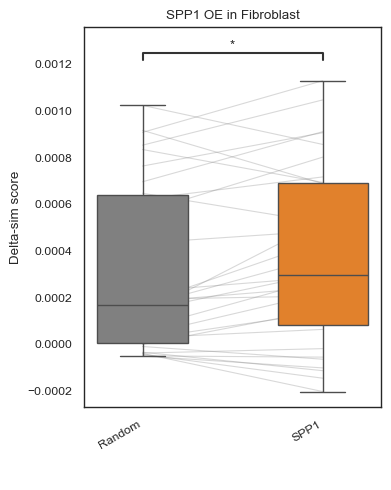

In [11]:
# Create the visualization
sns.set_theme(context='paper', style='white')

tu_isp_sim.vis_delta_emb_sim_boxbar(
    stats_filt,
    None,
    title_text=f"{groups_ordered[1]} OE in Fibroblast",
    ylabel_text="Delta-sim score",
    figsize=(4, 5),
    wilcoxon_test="less",
    line=True,
    line_params=None,
    pair_id_col="patch_id",
    **plot_params
)

# Customize x-axis labels
plt.xticks(range(2), ["Random", groups_ordered[1]], rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Interpretation

The plot shows the distribution of delta similarity scores for:
- **Random**: Background distribution from random gene perturbations in Fibroblast
- **SPP1**: Target gene (SPP1) overexpression in Fibroblast

Key points to interpret:
1. **Higher scores** indicate greater similarity to the CRPC state
2. **Statistical significance** (p-value from one sided Wilcoxon test) indicates whether SPP1 perturbation has higher effect than random genes in Fibroblast